# Recipe 09 — Fault tolerance on the nonlinear B747

This experiment compares **roll and heading regulation** before and after the left outer
engine fails. All controllers fly the same nonlinear 12-state B747, with the same initial
condition, surface magnitude/slew limits and longitudinal speed/altitude hold.
The commands are explicit: **roll = 0°, heading = 0°**.

The native `EngineFailureEvent` reduces thrust and creates the asymmetric yawing moment;
no artificial kick is added to an observation. The controller is never told the fault time
or remaining engine thrust. AA-INDI keeps its observer and VFF-RLS updates active throughout.

AA-INDI uses the current implementation associated with
[Atmaca et al. (2026)](https://doi.org/10.2514/6.2026-1743).
The public `tensoraerospace.benchmark.B747EngineFailureBenchmark` composes
native aircraft dynamics and damage scheduling, SDK PID/LQR controllers, the
AA-INDI sensor adapter and library metrics. No sibling example is imported.
The companion Python file is a short runnable entry point to the same API.

Run the cells in order. The recipe covers nominal tuning, paired healthy/faulty runs,
explicit references, error/control-effort metrics and optional longer validation.
The nonlinear B737 [iADP](../reinforcement_learning/incremental_adp/example_iadp_fault_b737.ipynb)
and [AA-INDI](../reinforcement_learning/incremental_adp/example_aaindi_fault_b737.ipynb)
notebooks provide the separate elevator-authority-loss scenario.


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from tensoraerospace.benchmark import B747EngineFailureBenchmark

COLORS = {"AA-INDI": "#176b87", "PID": "#c77835", "LQR": "#8064a2", "LQI": "#4b9b75"}
plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.titlesize": 12,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "lines.linewidth": 1.7, "savefig.bbox": "tight"})


## 1. Flight condition, fault and physical effect

The aircraft starts at 20,000 ft and 674 ft/s, with 0.3° roll and 1° heading error.
It is commanded back to zero from the start. At 30 s, engine 1 loses all thrust.
The simulation lasts 90 s at 50 Hz. The fault is applied at the start of its physical
interval, so no RK4 stage changes the trajectory before the event.

The model has four engines. At a fixed flight condition and throttle, losing one removes
25% of total thrust. Its lateral position creates a yawing moment toward the failed engine.
A common PI/PD longitudinal hold changes throttle and elevator using measured speed,
altitude, pitch and pitch rate; it receives no fault notification.

The model applies surfaces as zero-order-held angles and computes quasi-steady engine
thrust; it does not simulate servo lag or engine spool dynamics. Every lateral controller
has the same **±8° surface range and 20°/s command slew limit**.


In [2]:
experiment = B747EngineFailureBenchmark(
    duration=90.0, dt=0.02, fault_time=30.0, engine_fraction=0.0, engine_id=1,
    initial_heading_deg=1.0, initial_roll_deg=0.3, seed=11,
)
from tensoraerospace.aerospacemodel.b747.nonlinear import default_parameters
from tensoraerospace.aerospacemodel.b747.nonlinear.damage import EngineFailureEvent
from tensoraerospace.aerospacemodel.b747.nonlinear.damage.state import B747DamageState
from tensoraerospace.aerospacemodel.b747.nonlinear.engine import jt9d_thrust_with_asymmetry
from tensoraerospace.aerospacemodel.b747.nonlinear.params import isa_speed_of_sound_ft_s

# Offline physical check. These values are not passed into any controller.
trim = experiment.nominal_trim()
params = default_parameters()
params.damage_state = B747DamageState.healthy()
mach = experiment.airspeed_ft_s / isa_speed_of_sound_ft_s(experiment.altitude_ft)
healthy_thrust, healthy_yaw = jt9d_thrust_with_asymmetry(trim.throttle, mach, experiment.altitude_ft, params)
EngineFailureEvent(trigger_time=30.0, engine_id=1, thrust_fraction=0.0).apply(params.damage_state)
faulty_thrust, faulty_yaw = jt9d_thrust_with_asymmetry(trim.throttle, mach, experiment.altitude_ft, params)
assert np.isclose(faulty_thrust / healthy_thrust, 0.75)
assert faulty_yaw < 0
physical_check = pd.DataFrame({
    "Healthy": [healthy_thrust, healthy_yaw],
    "Engine 1 out, same throttle": [faulty_thrust, faulty_yaw],
}, index=["Total thrust [lbf]", "Engine yaw moment [lbf·ft]"])
display(physical_check.style.format(precision=3))


,Healthy,"Engine 1 out, same throttle"
Total thrust [lbf],42334.498,31750.874
Engine yaw moment [lbf·ft],0.000,-758845.884


## 2. Nominal controller design and tuning

- **PID:** independent roll/heading loops, derivative on measured angle, conditional
  anti-windup for magnitude and slew limits. The search includes the existing healthy-tuned
  PID gains and six variants with stronger integral action or reduced proportional gain.
- **LQR:** full lateral state `[beta, p, r, roll, heading]`; a discrete Riccati design from
  the healthy local nonlinear transition. Five state/input-weight settings are assessed.
- **LQI:** an additional baseline with integrated roll/heading errors. It uses the same
  Riccati design plus two bounded integral states and its own healthy-only weight search.
- **AA-INDI:** the outer attitude loop has gain 0.15 1/s and rate feedback 0.5 1/s.
  The nominal aileron/rudder derivatives are computed once on the healthy aircraft.
  The observer receives SI IMU, independent NED velocity/attitude, airspeed/density and
  actual surface feedback. All sensors are ideal in this experiment.

The baseline search uses a **separate healthy 60 s episode** with larger initial errors
(1° roll, 2° heading). It minimizes mean squared roll/heading error plus `0.002` times
squared surface deflection, all in degrees. It does not evaluate a fault trajectory.
Every candidate and its cost are displayed; this bounded search is not a global optimum.

For AA-INDI, `covariance_init=0.001` expresses confidence in the nominal derivative prior;
the acceleration filter is 5 Hz. Angular HOSM drift scales are `1e-4` rad to reduce
finite-step chattering at 50 Hz. Correction remains enabled. This tuning is for the
ideal-sensor engine-out test; sensor-bias detection performance is not being claimed.


In [3]:
settings, tuning_trials = experiment.tune_baselines()
tuning_table = pd.DataFrame([{
    "Controller": trial["algorithm"],
    "Healthy cost": trial["healthy_cost"],
    "Parameters": str({k: np.round(v, 5).tolist() if isinstance(v, np.ndarray) else v
                       for k, v in trial["settings"].items()}),
} for trial in tuning_trials])
display(tuning_table.style.format({"Healthy cost": "{:.6f}"}))
print("Selected nominal settings:")
for name, value in settings.items():
    print(name, value)


,Controller,Healthy cost,Parameters
0,PID,0.530962,"{'pid_gains': [27.72535, 0.65237, 4.72924, 1.34289, 0.02605, 6.60921]}"
1,PID,0.697538,"{'pid_gains': [13.86268, 0.65237, 4.72924, 0.67145, 0.02605, 6.60921]}"
2,PID,0.639303,"{'pid_gains': [27.72535, 1.95712, 4.72924, 1.34289, 0.07816, 6.60921]}"
3,PID,0.826615,"{'pid_gains': [13.86268, 1.95712, 4.72924, 0.67145, 0.07816, 6.60921]}"
4,PID,3.515111,"{'pid_gains': [13.86268, 6.52374, 4.72924, 0.67145, 0.26054, 6.60921]}"
5,PID,1.217584,"{'pid_gains': [6.93134, 1.95712, 3.54693, 0.33572, 0.07816, 4.95691]}"
6,PID,1.992541,"{'pid_gains': [27.72535, 6.52374, 4.72924, 1.34289, 0.26054, 6.60921]}"
7,LQR,1.048991,"{'lqr_settings': {'input_weight': 0.2, 'angle_weight': 1}}"
8,LQR,0.740916,"{'lqr_settings': {'input_weight': 0.05, 'angle_weight': 1}}"
9,LQR,1.402242,"{'lqr_settings': {'input_weight': 0.8, 'angle_weight': 1}}"


Selected nominal settings:
PID {'pid_gains': array([2.77253509e+01, 6.52373755e-01, 4.72924370e+00, 1.34289302e+00,
       2.60541651e-02, 6.60920861e+00])}
LQR {'lqr_settings': {'input_weight': 0.2, 'angle_weight': 4}}
LQI {'lqr_settings': {'input_weight': 0.2, 'angle_weight': 1}}


## 3. Paired healthy and failed-engine rollouts

Each controller starts fresh from its nominal initialization for both cases. The physical
state and action histories must match exactly up to the fault. Online AA-INDI learning
continues every step; there is no event-dependent freeze, gain switch or reset.

The engine fault adds a propulsion disturbance and changes airspeed. It does **not** damage
the aileron or rudder. The control-only moment regression can absorb unmodeled aerodynamic
and engine moments, so its fitted coefficients are not a measurement of engine health.
Any tracking advantage below is a result of the complete AA-INDI control architecture;
this experiment does not isolate parameter learning as the sole cause.


In [4]:
runs = {}
for algorithm in experiment.algorithms:
    for failed in (False, True):
        runs[(algorithm, failed)] = experiment.run(algorithm, fault=failed, **settings.get(algorithm, {}),
        )
        print(f"{algorithm:7s} | {'engine out' if failed else 'healthy':10s} | "
              f"{len(runs[(algorithm, failed)]['actions'])} completed transitions")
    index = round(experiment.fault_time / experiment.dt)
    np.testing.assert_array_equal(runs[(algorithm, False)]["states"][:index + 1],
                                  runs[(algorithm, True)]["states"][:index + 1])
    np.testing.assert_array_equal(runs[(algorithm, False)]["actions"][:index],
                                  runs[(algorithm, True)]["actions"][:index])
assert runs[("AA-INDI", True)]["updates"] == [experiment.steps] * 3
print("AA-INDI identification updates per moment axis:", runs[("AA-INDI", True)]["updates"])


AA-INDI | healthy    | 4500 completed transitions


AA-INDI | engine out | 4500 completed transitions


PID     | healthy    | 4500 completed transitions


PID     | engine out | 4500 completed transitions


LQR     | healthy    | 4500 completed transitions


LQR     | engine out | 4500 completed transitions


LQI     | healthy    | 4500 completed transitions


LQI     | engine out | 4500 completed transitions
AA-INDI identification updates per moment axis: [4500, 4500, 4500]


## 4. Reference signals and attitude response

Dashed horizontal lines show the zero roll/heading commands. The healthy panels show
nominal regulation quality; the engine-out panels retain the same scale and initial state.
The vertical line marks the event for evaluation only.


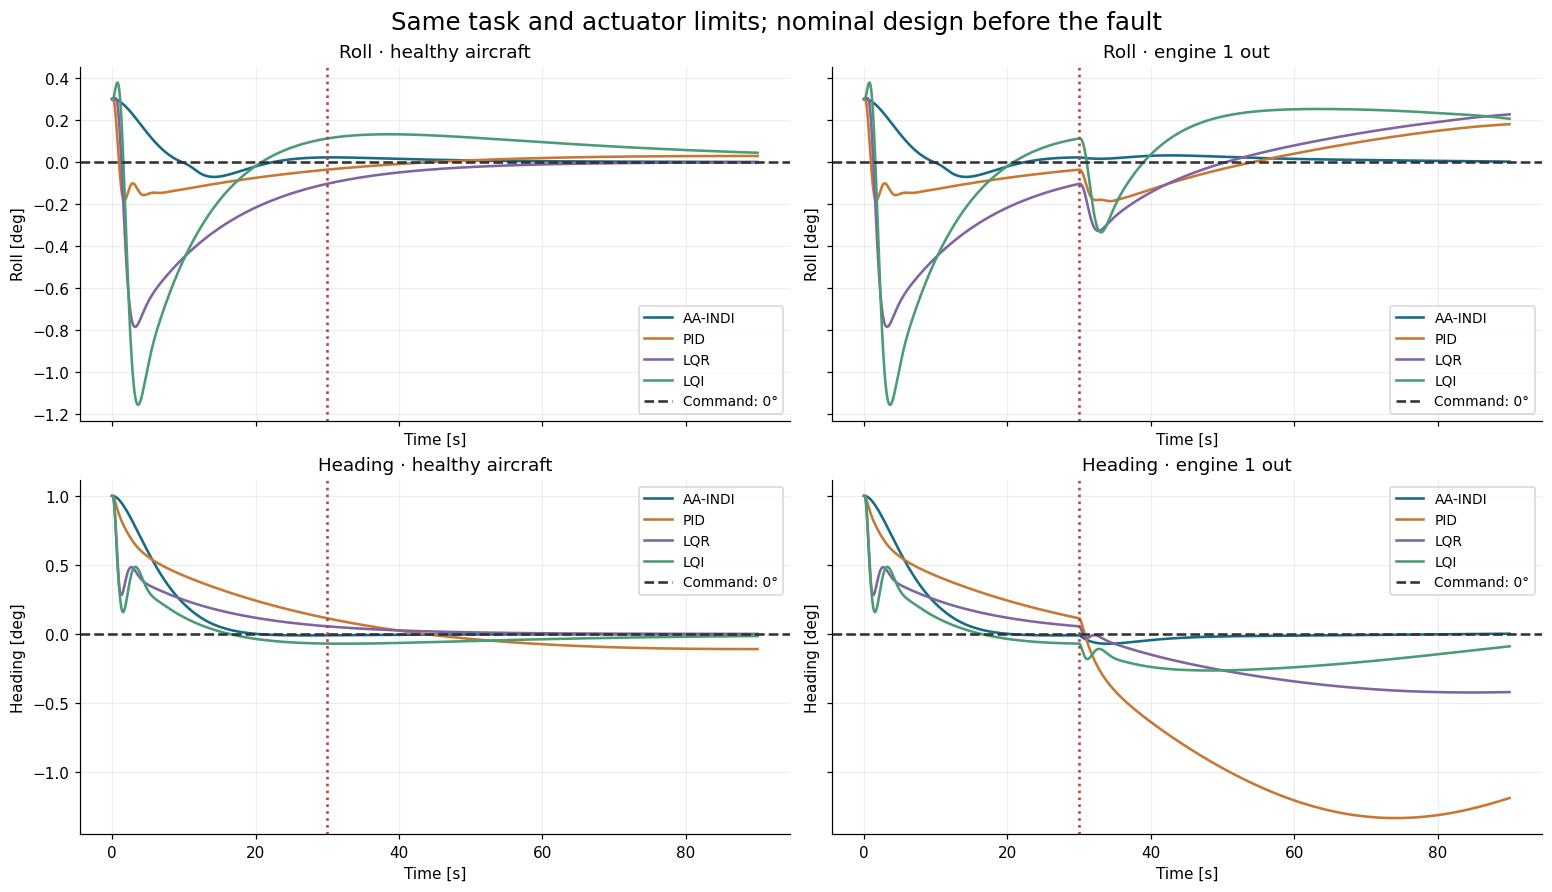

In [5]:
time = np.arange(experiment.steps + 1) * experiment.dt
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey="row", constrained_layout=True)
for column, failed in enumerate((False, True)):
    for algorithm in experiment.algorithms:
        state = runs[(algorithm, failed)]["states"]
        for row, index in enumerate((6, 8)):
            axes[row, column].plot(time, np.rad2deg(state[:, index]),
                                   color=COLORS[algorithm], label=algorithm)
    for row, name in enumerate(("Roll", "Heading")):
        ax = axes[row, column]
        ax.axhline(0, color="#333333", linestyle="--", label="Command: 0°")
        ax.axvline(experiment.fault_time, color="#b44040", linestyle=":")
        ax.set(title=f"{name} · {'engine 1 out' if failed else 'healthy aircraft'}",
               ylabel=f"{name} [deg]", xlabel="Time [s]")
        ax.grid(alpha=0.22)
        ax.legend(fontsize=9, loc="best")
fig.suptitle("Same task and actuator limits; nominal design before the fault", fontsize=16)
plt.show()


## 5. Quantify tracking and control effort

The post-fault interval is `(30, 90]` s. Combined RMSE is
`sqrt(mean(roll_error² + heading_error²))`; combined IAE sums absolute errors of both angles
and multiplies by `dt`. Both use degrees. Recovery requires **both** errors to remain inside
±0.05° for the rest of the interval. `Not reached` is retained rather than replaced with
the end of the simulation.

Control RMS is over both surfaces and the whole selected interval. Total variation sums
absolute changes between consecutive commands inside the interval; it indicates rapid
surface activity but is not a validated actuator-wear model. Healthy and failed-engine
metrics are both shown. A controller may improve tracking while using more surface effort.

This is disturbance rejection around a constant zero command, so step-response overshoot
relative to an almost-zero final output would be misleading. The B737 fault notebooks
provide the separate `ControlBenchmark` pitch-step examples.


In [6]:
metric_labels = {
    "roll_rmse_deg": "Roll RMSE [deg]", "heading_rmse_deg": "Heading RMSE [deg]",
    "combined_rmse_deg": "Combined RMSE [deg]", "angle_iae_deg_s": "Combined IAE [deg·s]",
    "peak_roll_deg": "Peak |roll| [deg]", "peak_heading_deg": "Peak |heading| [deg]",
    "recovery_s": "Recovery, ±0.05° [s]", "surface_rms_deg": "Surface RMS [deg]",
    "surface_peak_deg": "Peak |surface| [deg]", "surface_total_variation_deg": "Surface variation [deg]",
    "peak_speed_error_ft_s": "Peak speed error [ft/s]", "peak_height_error_ft": "Peak height error [ft]",
}
post_fault_table = pd.DataFrame({name: runs[(name, True)]["after"] for name in experiment.algorithms}).rename(index=metric_labels)
display(post_fault_table.style.format(precision=5, na_rep="Not reached"))
healthy_table = pd.DataFrame({name: runs[(name, False)]["whole"] for name in experiment.algorithms}).rename(index=metric_labels)
display(Markdown("### Healthy aircraft: complete 90 s episode"))
display(healthy_table.style.format(precision=5, na_rep="Not reached"))

adaptive_rmse = runs[("AA-INDI", True)]["after"]["combined_rmse_deg"]
for baseline in ("PID", "LQR", "LQI"):
    baseline_rmse = runs[(baseline, True)]["after"]["combined_rmse_deg"]
    print(f"Combined post-fault RMSE change relative to {baseline}: "
          f"{100 * (adaptive_rmse / baseline_rmse - 1):+.2f}%")


,AA-INDI,PID,LQR,LQI
Roll RMSE [deg],0.01810,0.11683,0.15784,0.21840
Heading RMSE [deg],0.02692,1.07988,0.32350,0.20630
Combined RMSE [deg],0.03243,1.08618,0.35995,0.30043
Combined IAE [deg·s],2.03693,67.48585,26.10714,24.43503
Peak |roll| [deg],0.03178,0.18613,0.32760,0.33451
Peak |heading| [deg],0.06979,1.33040,0.42213,0.26302
"Recovery, ±0.05° [s]",8.68000,Not reached,Not reached,Not reached
Surface RMS [deg],3.03004,3.16581,2.16848,2.34859
Peak |surface| [deg],4.89359,7.33813,2.91473,3.78214
Surface variation [deg],16.89003,19.68808,9.74745,11.23204


### Healthy aircraft: complete 90 s episode

,AA-INDI,PID,LQR,LQI
Roll RMSE [deg],0.06171,0.06569,0.22646,0.27554
Heading RMSE [deg],0.22224,0.25226,0.15283,0.13080
Combined RMSE [deg],0.23065,0.26067,0.27321,0.30500
Combined IAE [deg·s],9.48559,19.60513,18.66173,21.67319
Peak |roll| [deg],0.30000,0.29999,0.78452,1.15546
Peak |heading| [deg],0.99999,0.99995,0.99995,0.99995
"Recovery, ±0.05° [s]",17.24000,Not reached,39.82000,85.22000
Surface RMS [deg],2.45921,1.79137,1.33092,1.71396
Peak |surface| [deg],8.00000,6.74947,6.44996,5.97211
Surface variation [deg],25.90135,29.99128,32.42566,26.05992


Combined post-fault RMSE change relative to PID: -97.01%
Combined post-fault RMSE change relative to LQR: -90.99%
Combined post-fault RMSE change relative to LQI: -89.20%


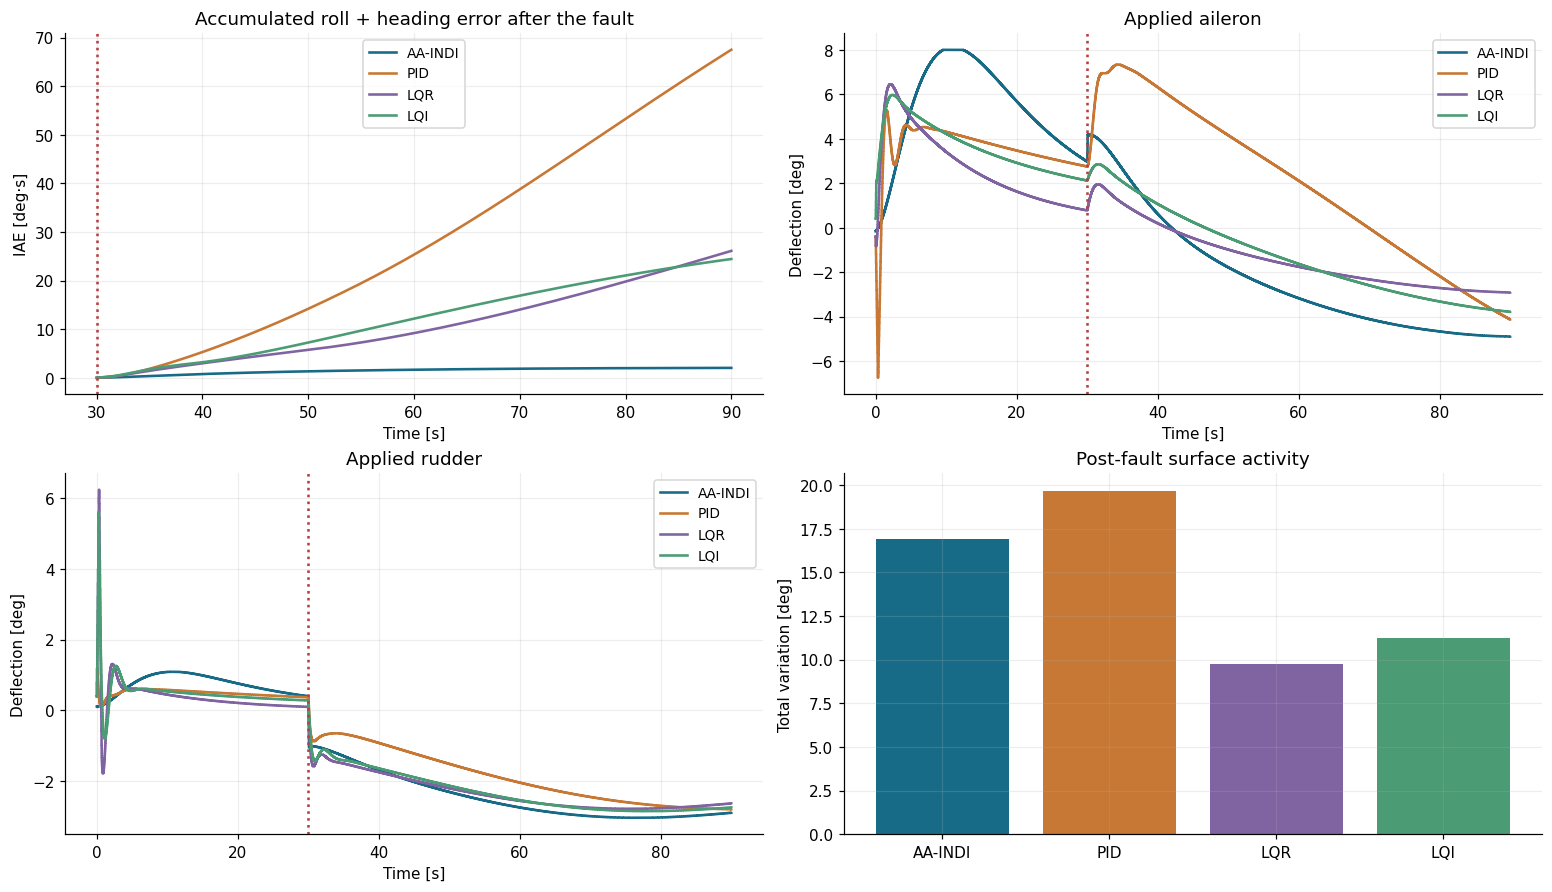

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)
mask = time > experiment.fault_time
for algorithm in experiment.algorithms:
    result = runs[(algorithm, True)]
    state, action = result["states"], result["actions"]
    angular_error = np.rad2deg(state[mask][:, [6, 8]])
    cumulative = np.cumsum(np.sum(np.abs(angular_error), axis=1)) * experiment.dt
    axes[0, 0].plot(time[mask], cumulative, color=COLORS[algorithm], label=algorithm)
    axes[0, 1].step(time[:-1], np.rad2deg(action[:, 1]), where="post", color=COLORS[algorithm], label=algorithm)
    axes[1, 0].step(time[:-1], np.rad2deg(action[:, 2]), where="post", color=COLORS[algorithm], label=algorithm)
axes[0, 0].set(title="Accumulated roll + heading error after the fault", ylabel="IAE [deg·s]")
axes[0, 1].set(title="Applied aileron", ylabel="Deflection [deg]")
axes[1, 0].set(title="Applied rudder", ylabel="Deflection [deg]")
values = [runs[(name, True)]["after"]["surface_total_variation_deg"] for name in experiment.algorithms]
axes[1, 1].bar(experiment.algorithms, values, color=[COLORS[name] for name in experiment.algorithms])
axes[1, 1].set(title="Post-fault surface activity", ylabel="Total variation [deg]")
for axis in (axes[0, 0], axes[0, 1], axes[1, 0]):
    axis.axvline(experiment.fault_time, color="#b44040", linestyle=":")
    axis.set_xlabel("Time [s]")
    axis.legend(fontsize=9)
for axis in axes.ravel():
    axis.grid(alpha=0.22)
plt.show()


## 6. Flight physics and learning remain visible

The common longitudinal controller must compensate for the missing thrust. These curves
show speed, altitude, sideslip and throttle, so a good attitude result cannot conceal loss
of speed or height. The observer/identifier telemetry below is diagnostic only and never
changes the control law at the event time.


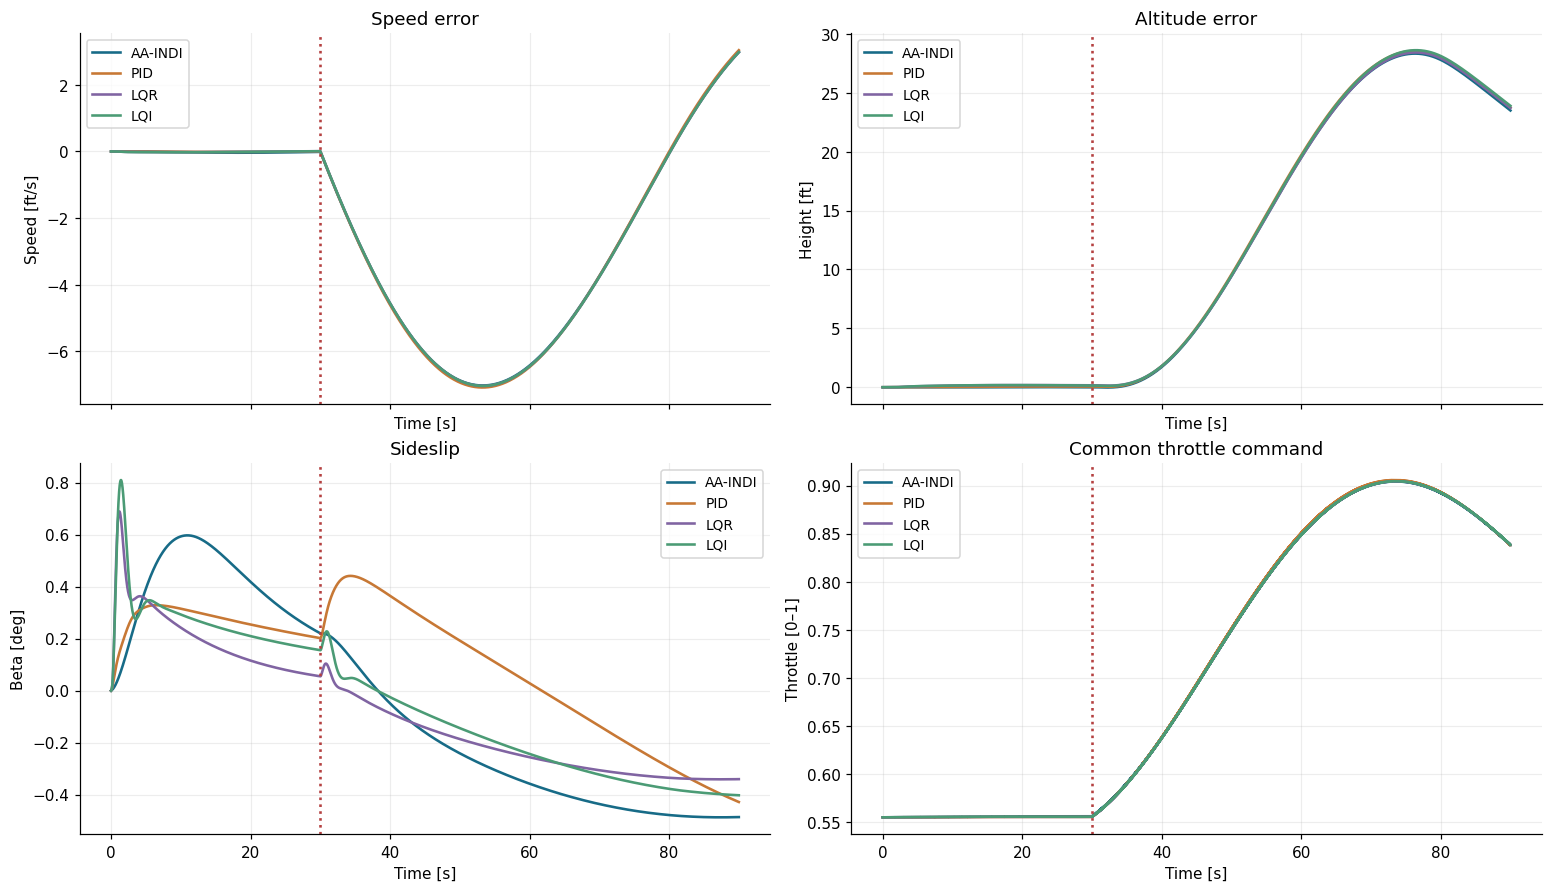

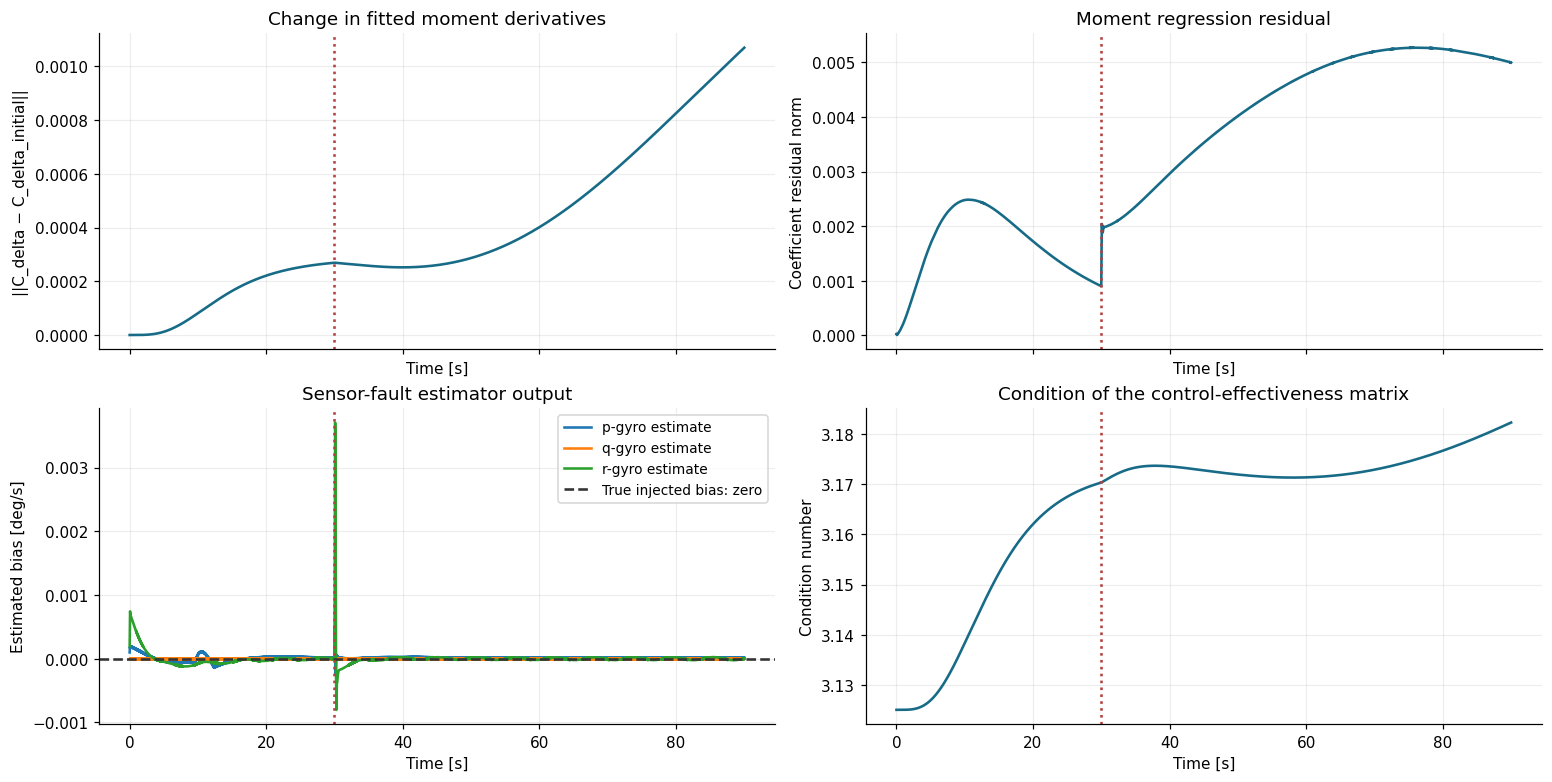

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, constrained_layout=True)
for algorithm in experiment.algorithms:
    result = runs[(algorithm, True)]
    state, action = result["states"], result["actions"]
    speed = np.linalg.norm(state[:, :3], axis=1)
    beta = np.rad2deg(np.arcsin(np.clip(state[:, 1] / speed, -1, 1)))
    axes[0, 0].plot(time, speed - experiment.airspeed_ft_s, color=COLORS[algorithm], label=algorithm)
    axes[0, 1].plot(time, -state[:, 11] - experiment.altitude_ft, color=COLORS[algorithm], label=algorithm)
    axes[1, 0].plot(time, beta, color=COLORS[algorithm], label=algorithm)
    axes[1, 1].step(time[:-1], action[:, 3], where="post", color=COLORS[algorithm], label=algorithm)
for axis, title, unit in zip(axes.ravel(), ["Speed error", "Altitude error", "Sideslip", "Common throttle command"],
                             ["Speed [ft/s]", "Height [ft]", "Beta [deg]", "Throttle [0–1]"]):
    axis.set(title=title, ylabel=unit, xlabel="Time [s]")
    axis.axvline(experiment.fault_time, color="#b44040", linestyle=":")
    axis.grid(alpha=0.22)
    axis.legend(fontsize=9)
plt.show()

learning = runs[("AA-INDI", True)]["learning"]
fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True, constrained_layout=True)
axes[0, 0].plot(time[1:], learning[:, 0], color=COLORS["AA-INDI"])
axes[0, 0].set(title="Change in fitted moment derivatives", ylabel="||C_delta − C_delta_initial||")
axes[0, 1].plot(time[1:], learning[:, 1], color=COLORS["AA-INDI"])
axes[0, 1].set(title="Moment regression residual", ylabel="Coefficient residual norm")
for index, axis_name in enumerate(("p", "q", "r")):
    axes[1, 0].plot(time[1:], learning[:, 2 + index], label=f"{axis_name}-gyro estimate")
axes[1, 0].axhline(0, color="#333333", linestyle="--", label="True injected bias: zero")
axes[1, 0].set(title="Sensor-fault estimator output", ylabel="Estimated bias [deg/s]")
axes[1, 0].legend(fontsize=9)
axes[1, 1].plot(time[1:], learning[:, 5], color=COLORS["AA-INDI"])
axes[1, 1].set(title="Condition of the control-effectiveness matrix", ylabel="Condition number")
for axis in axes.ravel():
    axis.axvline(experiment.fault_time, color="#b44040", linestyle=":")
    axis.set_xlabel("Time [s]")
    axis.grid(alpha=0.22)
plt.show()


## 7. Additional checks and interpretation

The saved [validation report](../../reports/aaindi-b747-engine-loss.md) evaluates the
same controllers without retuning for a right outer engine failure, a partial left-engine
loss at a different time, and a **500 s** simulation. The optional cell below reproduces
those longer checks; it is disabled by default to keep ordinary notebook reruns shorter.

Interpret the results as a local comparison of these configurations. AA-INDI can reject
an unexpected engine moment promptly through acceleration feedback, while fixed nominal
feedback designs have different disturbance-rejection dynamics. Tracking error, surface
activity and flight-envelope metrics must be assessed together. Online coefficient updates
remain active, but this is not a proof of parameter convergence or that online learning
alone caused the difference. Ideal sensors, simplified aerodynamics and missing servo/engine
lags limit transfer to a real aircraft.


In [9]:
RUN_EXTENDED_VALIDATION = False
if RUN_EXTENDED_VALIDATION:
    validation = experiment.validate_additional_cases(settings)
    validation_table = pd.DataFrame([
        {"Case": row["case"], "Controller": row["algorithm"], **row["after"]}
        for row in validation
    ]).rename(columns=metric_labels)
    display(validation_table)
else:
    display(Markdown("Extended runs were performed separately; see [the saved validation report](../../reports/aaindi-b747-engine-loss.md)."))


Extended runs were performed separately; see [the saved validation report](../../reports/aaindi-b747-engine-loss.md).